# 3. Funciones escalonadas

Temas selectos de aprendizaje de máquina \
Ana Luisa Llamas Martinez

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data

In [2]:
Wage = load_data('Wage')

Wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [3]:
Wage.shape

(3000, 11)

In [5]:
Wage.describe()

,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430


In [7]:
age = Wage['age']
wage = Wage['wage']

## 3.5.1 Dividir age utilizando cuantiles

In [ ]:
age_cut, cut_points = pd.qcut(age, q=4, retbins= True)
print('Puntos de corte')
print(cut_points)

Puntos de corte
[18.   33.75 42.   51.   80.  ]


In [9]:
print("Número de observaciones por grupo")
print(age_cut.value_counts().sort_index())

Número de observaciones por grupo
age
(17.999, 33.75]    750
(33.75, 42.0]      759
(42.0, 51.0]       817
(51.0, 80.0]       674
Name: count, dtype: int64


In [10]:
age_cut.cat.categories

IntervalIndex([(17.999, 33.75], (33.75, 42.0], (42.0, 51.0], (51.0, 80.0]], dtype='interval[float64, right]')

## 3.6 Variables indicadoras

In [68]:
X_cat = pd.get_dummies(age_cut).astype(float)

X = sm.add_constant(X_cat)

print("Matriz de diseño")
print(X.head())

Matriz de diseño
   const  (17.999, 33.75]  (33.75, 42.0]  (42.0, 51.0]  (51.0, 80.0]
0    1.0              1.0            0.0           0.0           0.0
1    1.0              1.0            0.0           0.0           0.0
2    1.0              0.0            0.0           1.0           0.0
3    1.0              0.0            0.0           1.0           0.0
4    1.0              0.0            0.0           1.0           0.0


## 3.8 Ajuste mediante mínimos cuadrados

In [17]:
modelo_ls = sm.OLS(wage, X).fit()
print("Regresión por mínimos cuadrados")
print(modelo_ls.summary())

Regresión por mínimos cuadrados
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     63.30
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.12e-39
Time:                        11:06:19   Log-Likelihood:                -15358.
No. Observations:                3000   AIC:                         3.072e+04
Df Residuals:                    2996   BIC:                         3.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         

## 3.10 Comprobación de los coeficientes

In [18]:
medias_grupos = (Wage
                 .assign(grupo_edad = age_cut)
                 .groupby('grupo_edad', observed = True)['wage']
                 .mean())

In [20]:
medias_grupos

grupo_edad
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
Name: wage, dtype: float64

In [21]:
modelo_ls.params

const            94.158392
(33.75, 42.0]    22.502418
(42.0, 51.0]     25.030273
(51.0, 80.0]     22.413324
dtype: float64

## 3.11.8 Intervalos de confianza

In [22]:
modelo_ls.t_test([1,1,0,0])

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0           116.6608      1.470     79.385      0.000     113.779     119.542

## 3.12 Predicciones mediante una función escalonada

In [23]:
age_grid = np.linspace(age.min(), age.max(), 1000)

In [24]:
cut_points

array([18.  , 33.75, 42.  , 51.  , 80.  ])

## 3.13 Clasificar las nuevas edades

In [26]:
cut_age_grid = pd.cut(age_grid, bins=cut_points, include_lowest=True)

## 3.13.1 Construir la matriz de diseño para las nuevas edades

In [27]:
X_grid_cat = pd.get_dummies(cut_age_grid, drop_first = True).astype(float)

In [28]:
X_grid_cat = X_grid_cat.reindex(columns = X_cat.columns, fill_value = 0)

In [29]:
X_grid = sm.add_constant(X_grid_cat, has_constant= 'add')

In [30]:
X_grid = X_grid[X.columns]

In [31]:
X_grid

,const,"(33.75, 42.0]","(42.0, 51.0]","(51.0, 80.0]"
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
995,1.0,0.0,0.0,1.0
996,1.0,0.0,0.0,1.0
997,1.0,0.0,0.0,1.0
998,1.0,0.0,0.0,1.0


## 3.14 Predicciones de mínimos cuadrados

In [32]:
pred_ls = modelo_ls.get_prediction(X_grid)

media_ls = pred_ls.predicted_mean

## 3.16 Intervalos de confianza

In [34]:
ic_ls = pred_ls.conf_int(alpha = 0.05)

## 3.17 Visualización del modelo lineal escalonado

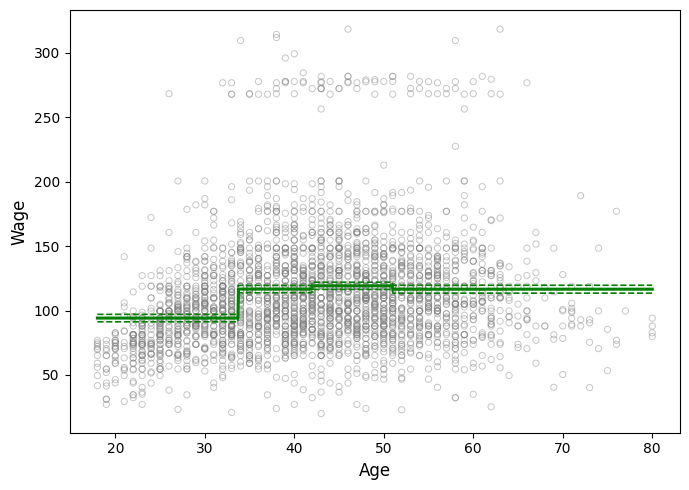

In [40]:
fig, ax = plt.subplots(figsize=(7,5))

#observaciones
ax.scatter(age, wage, facecolors = 'none', edgecolors= 'gray', alpha = 0.45, s=20, linewidths= 0.7)

#media estimada
ax.plot(age_grid, media_ls, color = 'green', linewidth = 2.2)

# Intervalos de confianza al 95%
ax.plot(age_grid, ic_ls[:,0], color = 'green', linestyle='--', linewidth=1.2)
ax.plot(age_grid, ic_ls[:,1], color = 'green', linestyle='--', linewidth=1.2)

#personalizar
ax.set_xlabel('Age', fontsize = 12)
ax.set_ylabel('Wage', fontsize= 12)

ax.tick_params(axis = 'both', labelsize = 10)

plt.tight_layout()
plt.show()

## 3.18 De regresión lineal a regresión logística

In [44]:
y_bin = (wage > 250).astype(int)

y_bin.head()

0    0
1    0
2    0
3    0
4    0
Name: wage, dtype: int64

In [45]:
y_bin.value_counts()

wage
0    2921
1      79
Name: count, dtype: int64

## 3.18.1 Función escalonada logística

In [46]:
modelo_logit = sm.Logit(y_bin, X).fit()


Optimization terminated successfully.
         Current function value: 0.118399
         Iterations 9


In [47]:
modelo_logit.params

const           -5.003946
(33.75, 42.0]    1.492401
(42.0, 51.0]     1.665384
(51.0, 80.0]     1.705028
dtype: float64

## 3.18.7 Odds ratios

In [48]:
np.exp(modelo_logit.params)

const            0.006711
(33.75, 42.0]    4.447761
(42.0, 51.0]     5.287706
(51.0, 80.0]     5.501538
dtype: float64

## 3.18.8 Transformar los coeficientes a probabilidades

In [50]:
b = modelo_logit.params

probabilidades_grupos = pd.Series([
    1 / (1 + np.exp(-b.iloc[0])),
    1 / (1 + np.exp(-(b.iloc[0] + b.iloc[1]))),
    1 / (1 + np.exp(-(b.iloc[0] + b.iloc[2]))),
    1 / (1 + np.exp(-(b.iloc[0] + b.iloc[3])))],
                                    index = age_cut.cat.categories

)

probabilidades_grupos

(17.999, 33.75]    0.006667
(33.75, 42.0]      0.028986
(42.0, 51.0]       0.034272
(51.0, 80.0]       0.035608
dtype: float64

## 3.18.17 Predicciones logísticas

In [52]:
pred_logit = modelo_logit.get_prediction(X_grid)

media_logit = pred_logit.predicted

## 3.18.18 Intervalos de confianza logísticos

In [53]:
ic_logit = pred_logit.summary_frame(alpha = 0.5)
ic_logit.head()

,predicted,se,ci_lower,ci_upper
0,0.006667,0.002971,0.004934,0.009002
1,0.006667,0.002971,0.004934,0.009002
2,0.006667,0.002971,0.004934,0.009002
3,0.006667,0.002971,0.004934,0.009002
4,0.006667,0.002971,0.004934,0.009002


In [54]:
ic_logit_low = ic_logit['ci_lower']
ic_logit_high = ic_logit['ci_upper']

## 3.18.19 Rug plot

In [55]:
rugh_high = age[y_bin == 1]
rugh_low = age[y_bin == 0]


## 3.18.20 Visualización de la regresión logística escalonada

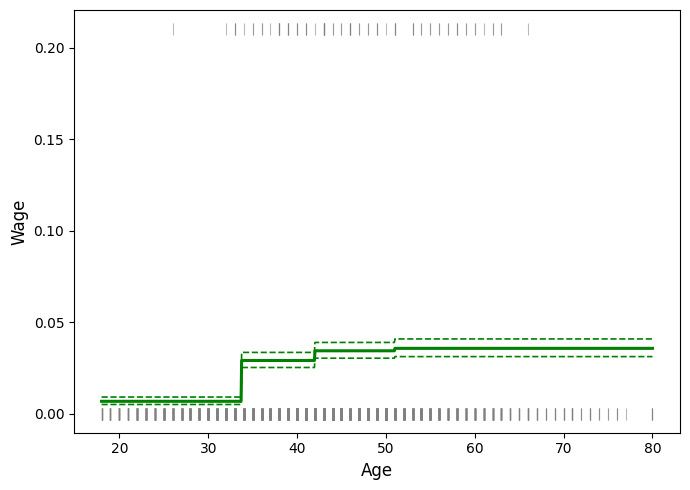

In [65]:
fig, ax = plt.subplots(figsize=(7,5))

#media estimada
ax.plot(age_grid, media_logit, color = 'green', linewidth = 2.2)

# Intervalos de confianza al 95%
ax.plot(age_grid, ic_logit_low, color = 'green', linestyle='--', linewidth=1.2)
ax.plot(age_grid, ic_logit_high, color = 'green', linestyle='--', linewidth=1.2)

y_min = 0
y_max = 0.21

ax.plot(
    rugh_high,
    np.full(
        len(rugh_high),
        y_max
    ),
    '|',
    color = 'gray',
    alpha = 0.55,
    markersize = 8,
    markeredgewidth = 0.8
)

ax.plot(
    rugh_low,
    np.full(
        len(rugh_low),
        y_min
    ),
    '|',
    color = 'gray',
    alpha = 0.55,
    markersize = 8,
    markeredgewidth = 0.8
)

#personalizar
ax.set_xlabel('Age', fontsize = 12)
ax.set_ylabel('Wage', fontsize= 12)

ax.tick_params(axis = 'both', labelsize = 10)

plt.tight_layout()
plt.show()

## 3.19 Ejercicios

**3.19.1 Ejercicio 1.** Repite el análisis de Wage utilizando los mismos cuatro grupos de edad, pero ahora construye el modelo con cuatro variables indicadoras y sin intercepto.

1) Ajusta el modelo de mínimos cuadrados.

In [69]:
#cuatro variables indicadoras y sin intercepto
age_cut1, cut_points1 = pd.qcut(age, q=4, retbins= True)

X_cat1 = pd.get_dummies(age_cut1).astype(float)
X1 = X_cat1

#Ajuste dee modelo de mínimos cuadrados
modelo_ls1 = sm.OLS(wage, X1).fit()

2) Interpreta los coeficientes estimados.

In [70]:
print("Regresión por mínimos cuadrados")
print(modelo_ls1.summary())

Regresión por mínimos cuadrados
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     63.30
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.12e-39
Time:                        10:44:23   Log-Likelihood:                -15358.
No. Observations:                3000   AIC:                         3.072e+04
Df Residuals:                    2996   BIC:                         3.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
(17.999, 3

**R:** \$94.15 es el salario promedio del grupo $(17.999, 33.75]$; \$116.66, de $(33.75, 42.0]$; \$119.18, de $(42.0, 51.0]$; \$116.57, de $(51.0, 80.0]$.

3) Verifica que cada coeficiente coincida con la media salarial del grupo correspondiente.

In [89]:
print("====== Medias por grupo =====")
print("=============================")
print(medias_grupos)

====== Medias por grupo =====
grupo_edad
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
Name: wage, dtype: float64


In [91]:
print("======== Coeficientes =======")
print("=============================")
modelo_ls1.params

======== Coeficientes =======


(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
dtype: float64

4) Ajusta también el modelo logístico para
    $$ Y = I(Wage > 250)$$

In [73]:
#Ajusta de modelo logístico para Y = I(Wage > 250)
y_bin1 = (wage > 250).astype(int)
modelo_logit1 = sm.Logit(y_bin1, X1).fit()

Optimization terminated successfully.
         Current function value: 0.118399
         Iterations 9


5) Transforma los coeficientes logísticos en probabilidades.

In [75]:
b1 = modelo_logit1.params

probabilidades_grupos1 = pd.Series([
    1 / (1 + np.exp(-b1.iloc[0])),
    1 / (1 + np.exp(-(b1.iloc[0] + b1.iloc[1]))),
    1 / (1 + np.exp(-(b1.iloc[0] + b1.iloc[2]))),
    1 / (1 + np.exp(-(b1.iloc[0] + b1.iloc[3])))],
                                    index = age_cut.cat.categories

)

print(probabilidades_grupos1)

(17.999, 33.75]    0.006667
(33.75, 42.0]      0.000200
(42.0, 51.0]       0.000238
(51.0, 80.0]       0.000248
dtype: float64


6) Compara las predicciones obtenidas con las del modelo con intercepto.

In [76]:
print("Coeficientes logísticos del modelo con intercepto")
print(probabilidades_grupos)

print("Coeficientes logísticos del modelo sin intercepto")
print(probabilidades_grupos1)

Coeficientes logísticos del modelo con intercepto
(17.999, 33.75]    0.006667
(33.75, 42.0]      0.028986
(42.0, 51.0]       0.034272
(51.0, 80.0]       0.035608
dtype: float64
Coeficientes logísticos del modelo sin intercepto
(17.999, 33.75]    0.006667
(33.75, 42.0]      0.000200
(42.0, 51.0]       0.000238
(51.0, 80.0]       0.000248
dtype: float64


Explica qué cambia entre ambas parametrizaciones y qué permanece igual.\
    **R:** Los coeficientes son diferentes, mientras que los rangos se mantuvieron.

**3.19.2 Ejercicio 2.** En lugar de dividir Age en cuatro grupos, construye una función escalonada utilizando seis grupos definidos mediante cuantiles.

1) Ajusta el modelo de mínimos cuadrados.

In [93]:
#seis variables indicadoras y sin intercepto
age_cut2, cut_points2 = pd.qcut(age, q=6, retbins= True)

X_cat2 = pd.get_dummies(age_cut2).astype(float)
X2 = X_cat2

#Ajuste de modelo de mínimos cuadrados
modelo_ls2 = sm.OLS(wage, X2).fit()

2) Grafica la función escalonada estimada con sus intervalos de confianza.

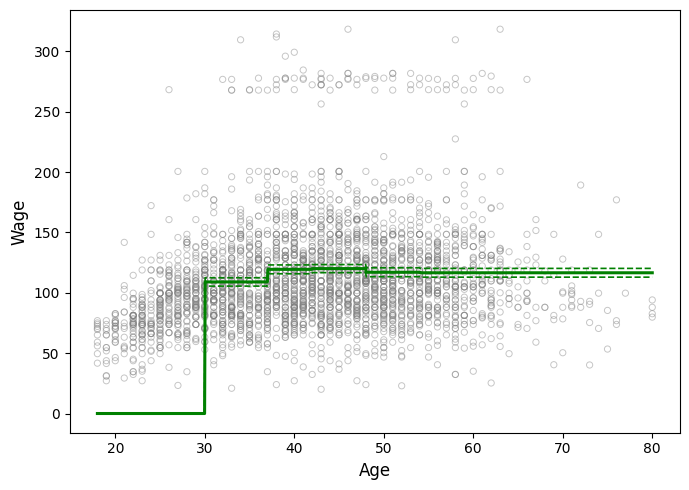

In [96]:
cut_age_grid2 = pd.cut(age_grid, bins=cut_points2, include_lowest=True)

X_grid_cat2 = pd.get_dummies(cut_age_grid2, drop_first = True).astype(float)
X_grid_cat2 = X_grid_cat2.reindex(columns = X_cat2.columns, fill_value = 0)
X_grid2 = sm.add_constant(X_grid_cat2, has_constant= 'add')
X_grid2 = X_grid2[X2.columns]

pred_ls2 = modelo_ls2.get_prediction(X_grid2)
media_ls2 = pred_ls2.predicted_mean
ic_ls2 = pred_ls2.conf_int(alpha = 0.05)

fig2, ax2 = plt.subplots(figsize=(7,5))

ax2.scatter(age, wage, facecolors = 'none', edgecolors= 'gray', alpha = 0.45, s=20, linewidths= 0.7)
ax2.plot(age_grid, media_ls2, color = 'green', linewidth = 2.2)

ax2.plot(age_grid, ic_ls2[:,0], color = 'green', linestyle='--', linewidth=1.2)
ax2.plot(age_grid, ic_ls2[:,1], color = 'green', linestyle='--', linewidth=1.2)

ax2.set_xlabel('Age', fontsize = 12)
ax2.set_ylabel('Wage', fontsize= 12)

ax2.tick_params(axis = 'both', labelsize = 10)

plt.tight_layout()
plt.show()

3) Compara el resultado con el modelo de cuatro grupos.\
**R:** Son similares.

4) Analiza cómo cambia la flexibilidad del modelo.\
**R:** Al aumentar el número de intervalos, también lo hace la flexibilidad del modelo.

5) Comenta qué ocurre con el número de observaciones dentro de cada intervalo y con la incertidumbre de las estimaciones.\
**R:** Al aumentar el número intervalos, el número de observaciones por cada uno diminuye. No obstante, la varianza aumenta.

Relaciona tus observaciones con el compromiso entre sesgo y varianza.

**R:** Recuperando un poco lo anterior mencionado, el aumento en el número de intervalos hace que la flexibilidad también lo haga y, por consecuencia, disminuya el sesgo. Sin embargo, la varianza aumenta.
Por otra parte, si el número de intervalos es bajo, el modelo no es flexible y, por ende, su sesgo es mayor, pero se compensa con una varianza baja.

**3.19.3 Ejercicio 3.** En el análisis anterior definimos
$$
Y = I(Wage > 250).
$$
Repite el modelo logístico utilizando ahora los siguientes umbrales:
$$
Y = I(Wage > 150),
$$
$$
Y = I(Wage > 200)
$$
y
$$
Y = I(Wage > 250)
$$.

Para cada umbral:

1) ajusta el modelo logístico utilizando los mismos cuatro grupos de edad;

In [98]:
age_cut3, cut_points3 = pd.qcut(age, q=4, retbins= True)

X_cat3 = pd.get_dummies(age_cut3).astype(float)
X3 = X_cat3

#modelo 1
y_bin31 = (wage > 150).astype(int)
modelo_logit31 = sm.Logit(y_bin31, X3).fit()

#modelo 2
y_bin32 = (wage > 200).astype(int)
modelo_logit32 = sm.Logit(y_bin32, X3).fit()

#modelo 3
y_bin33 = (wage > 250).astype(int)
modelo_logit33 = sm.Logit(y_bin33, X3).fit()

Optimization terminated successfully.
         Current function value: 0.340418
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.141153
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.118399
         Iterations 9


2) calcula las probabilidades estimadas para cada grupo;

In [108]:
b31 = modelo_logit31.params
b32 = modelo_logit32.params
b33 = modelo_logit33.params


probabilidades_grupos31 = pd.Series([
    1 / (1 + np.exp(-b31.iloc[0])),
    1 / (1 + np.exp(-(b31.iloc[0] + b31.iloc[1]))),
    1 / (1 + np.exp(-(b31.iloc[0] + b31.iloc[2]))),
    1 / (1 + np.exp(-(b31.iloc[0] + b31.iloc[3])))],
                                    index = age_cut3.cat.categories

)

probabilidades_grupos32 = pd.Series([
    1 / (1 + np.exp(-b32.iloc[0])),
    1 / (1 + np.exp(-(b32.iloc[0] + b32.iloc[1]))),
    1 / (1 + np.exp(-(b32.iloc[0] + b32.iloc[2]))),
    1 / (1 + np.exp(-(b32.iloc[0] + b32.iloc[3])))],
                                    index = age_cut3.cat.categories

)

probabilidades_grupos33 = pd.Series([
    1 / (1 + np.exp(-b33.iloc[0])),
    1 / (1 + np.exp(-(b33.iloc[0] + b33.iloc[1]))),
    1 / (1 + np.exp(-(b33.iloc[0] + b33.iloc[2]))),
    1 / (1 + np.exp(-(b33.iloc[0] + b33.iloc[3])))],
                                    index = age_cut3.cat.categories

)

print("Probabilidades del grupo 1")
print("=============================")
print(probabilidades_grupos31)

print("Probabilidades del grupo 2")
print("=============================")
print(probabilidades_grupos32)

print("Probabilidades del grupo 3")
print("=============================")
print(probabilidades_grupos33)

Probabilidades del grupo 1
(17.999, 33.75]    0.032000
(33.75, 42.0]      0.005338
(42.0, 51.0]       0.006444
(51.0, 80.0]       0.004370
dtype: float64
Probabilidades del grupo 2
(17.999, 33.75]    0.009333
(33.75, 42.0]      0.000347
(42.0, 51.0]       0.000421
(51.0, 80.0]       0.000439
dtype: float64
Probabilidades del grupo 3
(17.999, 33.75]    0.006667
(33.75, 42.0]      0.000200
(42.0, 51.0]       0.000238
(51.0, 80.0]       0.000248
dtype: float64


3) grafica la función escalonada correspondiente;

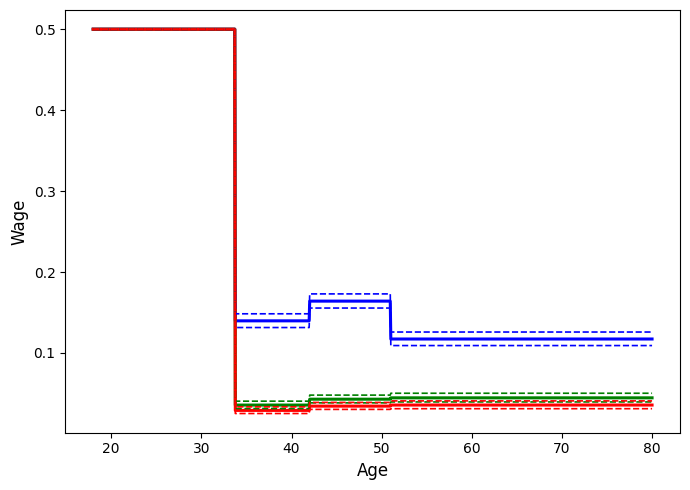

In [109]:
age_grid3 = np.linspace(age.min(), age.max(), 1000)

cut_age_grid3 = pd.cut(age_grid3, bins=cut_points3, include_lowest=True)
X_grid_cat3 = pd.get_dummies(cut_age_grid3, drop_first = True).astype(float)
X_grid_cat3 = X_grid_cat3.reindex(columns = X_cat3.columns, fill_value = 0)
X_grid3 = sm.add_constant(X_grid_cat3, has_constant= 'add')
X_grid3 = X_grid3[X3.columns]

#modelo 1
pred_logit31 = modelo_logit31.get_prediction(X_grid3)

media_logit31 = pred_logit31.predicted

ic_logit31 = pred_logit31.summary_frame(alpha = 0.5)

ic_logit_low31 = ic_logit31['ci_lower']
ic_logit_high31 = ic_logit31['ci_upper']

#modelo 2
pred_logit32 = modelo_logit32.get_prediction(X_grid3)

media_logit32 = pred_logit32.predicted

ic_logit32 = pred_logit32.summary_frame(alpha = 0.5)

ic_logit_low32 = ic_logit32['ci_lower']
ic_logit_high32 = ic_logit32['ci_upper']

#modelo 3
pred_logit33 = modelo_logit33.get_prediction(X_grid3)

media_logit33 = pred_logit33.predicted

ic_logit33 = pred_logit33.summary_frame(alpha = 0.5)

ic_logit_low33 = ic_logit33['ci_lower']
ic_logit_high33 = ic_logit33['ci_upper']

#gráfica
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(age_grid3, media_logit31, color = 'blue', linewidth = 2.2)
ax.plot(age_grid3, media_logit32, color = 'green', linewidth = 2.2)
ax.plot(age_grid3, media_logit33, color = 'red', linewidth = 2.2)

ax.plot(age_grid3, ic_logit_low31, color = 'blue', linestyle='--', linewidth=1.2)
ax.plot(age_grid3, ic_logit_high31, color = 'blue', linestyle='--', linewidth=1.2)

ax.plot(age_grid3, ic_logit_low32, color = 'green', linestyle='--', linewidth=1.2)
ax.plot(age_grid3, ic_logit_high32, color = 'green', linestyle='--', linewidth=1.2)

ax.plot(age_grid3, ic_logit_low33, color = 'red', linestyle='--', linewidth=1.2)
ax.plot(age_grid3, ic_logit_high33, color = 'red', linestyle='--', linewidth=1.2)


ax.set_xlabel('Age', fontsize = 12)
ax.set_ylabel('Wage', fontsize= 12)

ax.tick_params(axis = 'both', labelsize = 10)

plt.tight_layout()
plt.show()

4) compara cómo cambian las probabilidades al aumentar el umbral.

**R:** Las probabilidades más en disminución.

Explica por qué las probabilidades deben disminuir al utilizar umbrales más altos.

**R:** Porque es menos probable que existan personas con salarios demasiados altos.

**3.19.4 Ejercicio 4.** Construye dos funciones escalonadas para Age utilizando cuatro grupos:

- una mediante pd.qcut();
- otra mediante pd.cut()

Para cada caso:

1) identifica los puntos de corte;

In [112]:
age_cut41, cut_points41 = pd.qcut(age, q=4, retbins= True)
print('Puntos de corte con pd.qcut()')
print(cut_points41)

age_cut42, cut_points42 = pd.cut(age, 4, retbins= True)
print('Puntos de corte con pd.cut()')
print(cut_points42)

Puntos de corte con pd.qcut()
[18.   33.75 42.   51.   80.  ]
Puntos de corte con pd.cut()
[17.938 33.5   49.    64.5   80.   ]


2) calcula el número de observaciones por grupo;

In [113]:
print("Número de observaciones con pd.qcut()")
print(age_cut41.value_counts().sort_index())

print("Número de observaciones con pd.cut()")
print(age_cut42.value_counts().sort_index())

Número de observaciones con pd.qcut()
age
(17.999, 33.75]    750
(33.75, 42.0]      759
(42.0, 51.0]       817
(51.0, 80.0]       674
Name: count, dtype: int64
Número de observaciones con pd.cut()
age
(17.938, 33.5]     750
(33.5, 49.0]      1399
(49.0, 64.5]       779
(64.5, 80.0]        72
Name: count, dtype: int64


3) ajusta un modelo de mínimos cuadrados;

In [114]:
#con pd.qcut()
X_cat41 = pd.get_dummies(age_cut41).astype(float)
X41 = X_cat41

modelo_ls41 = sm.OLS(wage, X41).fit()

#con pd.cut()
X_cat42 = pd.get_dummies(age_cut42).astype(float)
X42 = X_cat42

modelo_ls42 = sm.OLS(wage, X42).fit()

4) compara las medias estimadas;

In [118]:
medias_grupos41 = (
    Wage
    .assign(grupo_edad=age_cut41)
    .groupby('grupo_edad', observed=True)['wage']
    .mean()
)

medias_grupos42 = (
    Wage
    .assign(grupo_edad=age_cut42)
    .groupby('grupo_edad', observed=True)['wage']
    .mean()
)

print("====== Medias con pd.qcut() =====")
print("=============================")
print(medias_grupos41)

print("====== Medias con pd.cut() =====")
print("=============================")
print(medias_grupos42)

====== Medias con pd.qcut() =====
grupo_edad
(17.999, 33.75]     94.158392
(33.75, 42.0]      116.660810
(42.0, 51.0]       119.188665
(51.0, 80.0]       116.571716
Name: wage, dtype: float64
====== Medias con pd.cut() =====
grupo_edad
(17.938, 33.5]     94.158392
(33.5, 49.0]      118.211883
(49.0, 64.5]      117.822951
(64.5, 80.0]      101.798984
Name: wage, dtype: float64


5) grafica ambas funciones escalonadas.

In [119]:
cut_age_grid41 = pd.cut(age_grid, bins=cut_points41, include_lowest=True)

X_grid_cat41 = pd.get_dummies(cut_age_grid41, drop_first = True).astype(float)
X_grid_cat41 = X_grid_cat41.reindex(columns = X_cat41.columns, fill_value = 0)
X_grid41 = sm.add_constant(X_grid_cat41, has_constant= 'add')
X_grid41 = X_grid41[X41.columns]

pred_ls41 = modelo_ls41.get_prediction(X_grid41)
media_ls41 = pred_ls41.predicted_mean
ic_ls41 = pred_ls41.conf_int(alpha = 0.05)

cut_age_grid42 = pd.cut(age_grid, bins=cut_points42, include_lowest=True)

X_grid_cat42 = pd.get_dummies(cut_age_grid42, drop_first = True).astype(float)
X_grid_cat42 = X_grid_cat42.reindex(columns = X_cat42.columns, fill_value = 0)
X_grid42 = sm.add_constant(X_grid_cat42, has_constant= 'add')
X_grid42 = X_grid42[X42.columns]

pred_ls42 = modelo_ls42.get_prediction(X_grid42)
media_ls42 = pred_ls42.predicted_mean
ic_ls42 = pred_ls42.conf_int(alpha = 0.05)

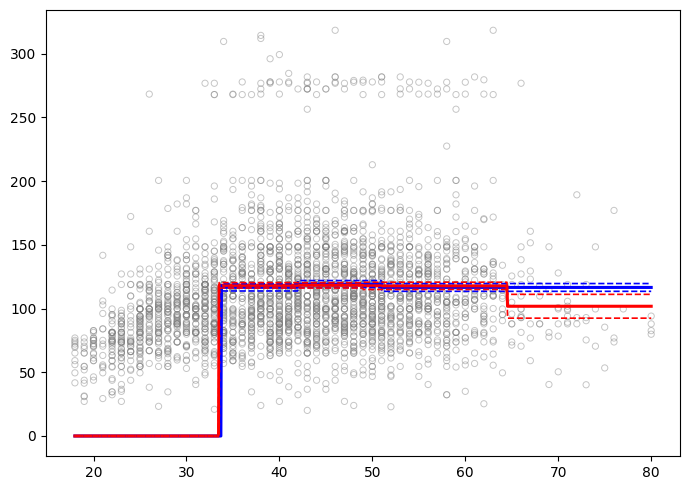

In [120]:
fig4, ax4 = plt.subplots(figsize=(7,5))

ax4.scatter(age, wage, facecolors = 'none', edgecolors= 'gray', alpha = 0.45, s=20, linewidths= 0.7)

ax4.plot(age_grid, media_ls41, color = 'blue', linewidth = 2.2)
ax4.plot(age_grid, media_ls42, color = 'red', linewidth = 2.2)

ax4.plot(age_grid, ic_ls41[:,0], color = 'blue', linestyle='--', linewidth=1.2)
ax4.plot(age_grid, ic_ls41[:,1], color = 'blue', linestyle='--', linewidth=1.2)
ax4.plot(age_grid, ic_ls42[:,0], color = 'red', linestyle='--', linewidth=1.2)
ax4.plot(age_grid, ic_ls42[:,1], color = 'red', linestyle='--', linewidth=1.2)

ax2.set_xlabel('Age', fontsize = 12)
ax2.set_ylabel('Wage', fontsize= 12)

ax2.tick_params(axis = 'both', labelsize = 10)

plt.tight_layout()
plt.show()

Discute las diferencias entre dividir el número de observaciones y dividir el rango de la variable.
Cuando dividimos en partes iguales el rango de la variable, no nos importa el número de observaciones que haya en cada intervalo; en cambio, dividir el rango por el número de observaciones, sí, aunque los rangos no necesariamente serán del mismo tamaño.

**3.19.5 Ejercicio 5.** Utiliza nuevamente el conjunto de datos Wage, pero ahora selecciona otra variable continua como predictor, por ejemplo year.

1) Explora gráficamente la relación entre esa variable y wage.

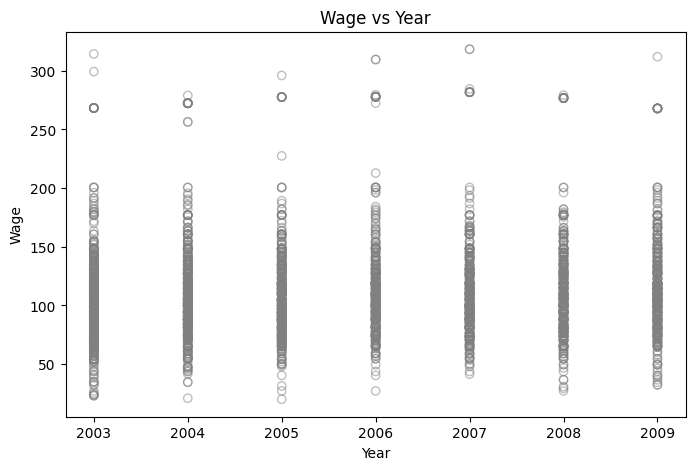

In [124]:
year = Wage['year']
wage = Wage['wage']

plt.figure(figsize=(8, 5))

plt.scatter(
    year,
    wage,
    facecolor='none',
    edgecolor='gray',
    alpha=0.5
)

plt.xlabel('Year')
plt.ylabel('Wage')
plt.title('Wage vs Year')

plt.show()

2) Divide el predictor en cuatro grupos mediante cuantiles.

In [125]:
year_cut5, cut_points5 = pd.qcut(year, q=4, retbins= True)
print('Puntos de corte')
print(cut_points5)

Puntos de corte
[2003. 2004. 2006. 2008. 2009.]


3) Ajusta una función escalonada mediante mínimos cuadrados.

In [126]:
X_cat5 = pd.get_dummies(year_cut5).astype(float)
X5 = X_cat5

#Ajuste de modelo de mínimos cuadrados
modelo_ls5 = sm.OLS(wage, X5).fit()

4) Interpreta los coeficientes.

In [127]:
print("======== Coeficientes =======")
print("=============================")
modelo_ls5.params

======== Coeficientes =======


(2002.999, 2004.0]    108.609537
(2004.0, 2006.0]      112.002400
(2006.0, 2008.0]      113.224127
(2008.0, 2009.0]      115.971771
dtype: float64

5) Construye una variable binaria basada en wage y ajusta una regresión logística escalonada.

In [128]:
y_bin5 = (wage > 200).astype(int)
modelo_logit5 = sm.Logit(y_bin5, X3).fit()

Optimization terminated successfully.
         Current function value: 0.141153
         Iterations 9


6) Compara el comportamiento del nuevo predictor con el observado para age.

In [129]:
year_grid5 = np.linspace(year.min(), year.max(), 1000)
cut_year_grid5 = pd.cut(year_grid5, bins=cut_points5, include_lowest=True)
X_grid_cat5 = pd.get_dummies(cut_year_grid5, drop_first = True).astype(float)
X_grid_cat5 = X_grid_cat5.reindex(columns = X_cat5.columns, fill_value = 0)
X_grid5 = sm.add_constant(X_grid_cat5, has_constant= 'add')
X_grid5 = X_grid5[X5.columns]

In [130]:
pred_logit5 = modelo_logit5.get_prediction(X_grid5)

media_logit5 = pred_logit5.predicted

ic_logit5 = pred_logit5.summary_frame(alpha = 0.5)

ic_logit_low5 = ic_logit5['ci_lower']
ic_logit_high5 = ic_logit5['ci_upper']

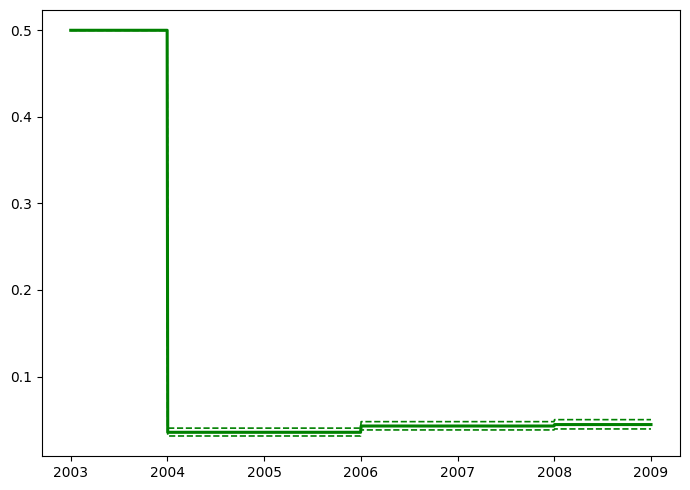

In [131]:
fig5, ax5 = plt.subplots(figsize=(7,5))

ax5.plot(year_grid5, media_logit5, color = 'green', linewidth = 2.2)

ax5.plot(year_grid5, ic_logit_low5, color = 'green', linestyle='--', linewidth=1.2)
ax5.plot(year_grid5, ic_logit_high5, color = 'green', linestyle='--', linewidth=1.2)

ax.set_xlabel('Year', fontsize = 12)
ax.set_ylabel('Wage', fontsize= 12)

ax.tick_params(axis = 'both', labelsize = 10)

plt.tight_layout()
plt.show()

Discute si una función escalonada parece apropiada para esa relación.

**R:** No, al contrario, parece innecesaria, dado que la relación año y salario parece lineal.